In [1]:
import ND_parser
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import paper_style

In [2]:
U235 = ND_parser.read_END_CSV("92-U235_MF3_MT18.csv").drop(index=[0, 1])
U235["Z"] = 92
U235["A"] = 235
U233 = ND_parser.read_END_CSV("92-U233_MF3_MT18.csv").drop(index=[0, 1])
U233["Z"] = 92
U233["A"] = 233
PU239 = ND_parser.read_END_CSV("94Pu239_MF3_MT18.csv").drop(index=[0, 1])
PU239["Z"] = 94
PU239["A"] = 239
Udat = pd.concat([
    U235.drop(columns=["JENDL/AD-2017"]),
    U233.drop(columns=["JENDL-4.0u"])
])
Udat["logE"] = np.log(Udat["Incident energy"])
Udat.head()

,Incident energy,BROND-3.1,ENDF/B-VIII.0,JEFF-4.0,TENDL-2019,Z,A,logE
2,0.000010,31399.140000,30933.410000,30973.037400,4627.861160,92,235,-11.512925
3,0.000010,30915.658590,30457.111790,30485.644400,4555.036908,92,235,-11.481205
4,0.000010,30915.583583,30457.037897,30485.572297,4555.025610,92,235,-11.481200
5,0.000011,30461.550000,30009.750000,30049.118961,4489.812550,92,235,-11.452301
6,0.000011,30420.474238,29969.284402,30005.987000,4483.367950,92,235,-11.449490


Saved → u_235_fission_evaluated.pdf


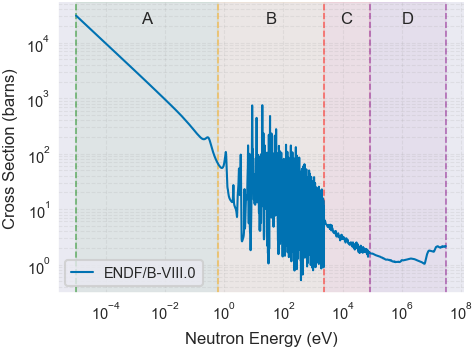

In [25]:
fig, ax = paper_style.fig("single")

ax.plot(U235["Incident energy"], U235["ENDF/B-VIII.0"], label="ENDF/B-VIII.0")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Neutron Energy (eV)")
ax.set_ylabel("Cross Section (barns)")
ax.legend()
ax.grid(True, which="both", alpha=0.2)

regions = [
    (1e-5,  0.625,  "green",  "A"),
    (0.625, 2.25e3, "orange", "B"),
    (2.25e3, 8e4, "red",    "C"),
    (8e4,  3e7,   "purple", "D"),
]

for xmin, xmax, color, label in regions:
    ax.axvspan(xmin, xmax, alpha=0.05, color=color, zorder=0)
    ax.axvline(xmin, color=color, linewidth=0.8, linestyle="--", alpha=0.5, zorder=1)

ax.axvline(3e7, color="purple", linewidth=0.8, linestyle="--", alpha=0.5, zorder=1)

trans = ax.get_xaxis_transform()
for xmin, xmax, color, label in regions:
    x_centre = (xmin * xmax) ** 0.5
    ax.text(x_centre, 0.97, label,
            transform=trans,
            ha="center", va="top")

plt.tight_layout()
paper_style.save("u_235_fission_evaluated.pdf")
plt.show()

In [32]:
X = Udat[["logE", "Z", "A"]]
y = Udat["ENDF/B-VIII.0"]
mask = Udat["ENDF/B-VIII.0"].notna()
X = X[mask]
y = y[mask]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#y_scaled = scaler.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.4, random_state=42
)

In [2]:
def process_endf_files(files):
    # Takes a list of files, returns a dataframe with all the relevant features/targets
    # File names structured: ZXA_MF3_MT$
    # X will always be 2 digits, as will Z, A, and MT will be 3
    dataframes = []
    for file in files:
        df = ND_parser.read_END_CSV(file).drop(index=[0,1])
        df["Z"] = int(file[:2])
        df["A"] = int(file[4:7])
        dataframes.append(df)

    full_df = pd.concat(dataframes)
    full_df["logE"] = np.log(full_df["Incident energy"])
    return full_df

In [53]:
Udat_new = process_endf_files(["92-U233_MF3_MT18.csv", "92-U235_MF3_MT18.csv"])
Udat_new = Udat_new.drop(columns=["JENDL-4.0u", "JENDL/AD-2017"])
Udat_new.head()

,Incident energy,BROND-3.1,ENDF/B-VIII.0,JEFF-4.0,TENDL-2019,Z,A,logE
2,0.000010,26869.950000,27012.490000,26949.168900,27002.884600,92,233,-11.512925
3,0.000010,26456.248243,26596.596671,26525.124000,26577.996017,92,233,-11.481205
4,0.000010,26456.184061,26596.532149,26525.061269,26577.930100,92,233,-11.481200
5,0.000011,26067.680000,26205.970000,26145.335618,26197.448885,92,233,-11.452301
6,0.000011,26032.532161,26170.635522,26107.809700,26159.848300,92,233,-11.449490


In [33]:
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

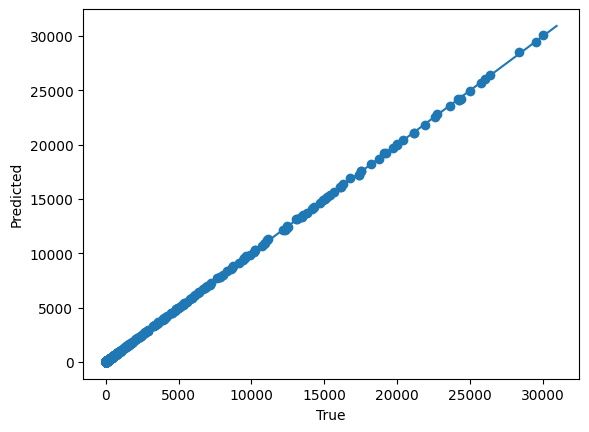

In [40]:
plt.scatter(y_test, model.predict(X_test))
plt.xlabel("True")
plt.ylabel("Predicted")
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.show()

In [55]:
y_pred = model.predict(X_test)
rel_err = (y_pred - y_test) / y_test

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MRE:", np.mean(np.abs(rel_err)))

R²: 0.999976699047992
RMSE: 3.5357484848620215
MAE: 0.27352022676156457
MRE: 0.005926126939566174


In [3]:
Udat_gp = ND_parser.read_END_CSV("u_235.csv").drop(index=[0, 1])
#Udat_gp["Prop k"] = np.sqrt(Udat_gp["Incident energy"])
Udat_gp["Incident energy"] = np.log(Udat_gp["Incident energy"])
#Udat_gp = Udat_gp[['Prop k', 'Incident energy'] + [c for c in Udat_gp if c not in ['Prop k', 'Incident energy']]]
Udat_gp.head()

,Incident energy,BROND-3.1,BROND-3.1_err,ENDF/B-VIII.0,ENDF/B-VIII.0_err,JEFF-4.0,JEFF-4.0_err,TENDL-2019,TENDL-2019_err
2,-11.512925,31399.140000,144.450071,30933.410000,242.559103,30973.037400,203.615627,30922.535700,242.473834
3,-11.481205,30915.658590,142.225840,30457.111790,238.824291,30485.644400,200.411523,30435.940190,238.658278
4,-11.481200,30915.583583,142.225495,30457.037897,238.823712,30485.572297,200.411049,30435.864700,238.657686
5,-11.452301,30461.550000,140.136738,30009.750000,235.316379,30049.118961,197.541820,30000.125579,235.240911
6,-11.449490,30420.474238,139.947771,29969.284402,234.999075,30005.987000,197.258272,29957.064200,234.903253


In [8]:
Udat_sub = Udat_gp.iloc[::5]
Udat_sub.to_csv("U_GP_sub_5.txt", index=False)

In [5]:
Udat_gp.to_csv("U_GP.txt", index=False)

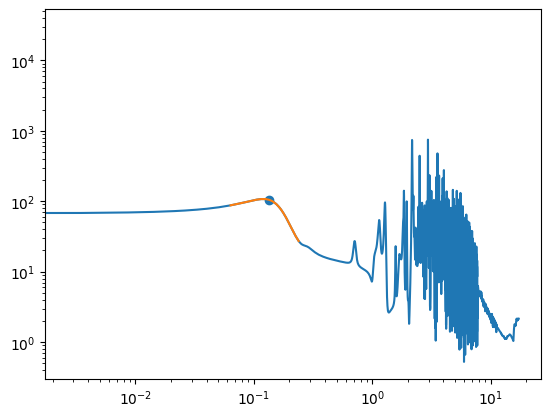

In [25]:
plt.plot(Udat_gp["Incident energy"], Udat_gp["ENDF/B-VIII.0"])
plt.scatter(Udat_gp["Incident energy"][1200], Udat_gp["ENDF/B-VIII.0"][1200])
plt.plot(Udat_gp["Incident energy"][1150:1300], Udat_gp["ENDF/B-VIII.0"][1150:1300])
plt.xscale("log")
plt.yscale("log")

In [40]:
gp_results = pd.read_csv("C:/Users/jakeh/PycharmProjects/ML4ND_py/Gaussian-Process/output_folder/U_GP_sub_5_GP_results.txt")
gp_results.columns = Udat_sub.columns
gp_results.head()

,Incident energy,BROND-3.1,BROND-3.1_err,ENDF/B-VIII.0,ENDF/B-VIII.0_err,JEFF-4.0,JEFF-4.0_err,TENDL-2019,TENDL-2019_err
0,-11.512925,2.105475,0.999973,0.838631,0.999990,0.970311,0.999987,0.840821,0.999990
1,-11.502925,2.252809,0.999972,0.899207,0.999989,1.033505,0.999987,0.901557,0.999989
2,-11.492925,2.390460,0.999971,0.957669,0.999988,1.090073,0.999987,0.960194,0.999988
3,-11.482925,2.520398,0.999971,1.013957,0.999988,1.142183,0.999987,1.016663,0.999988
4,-11.472925,2.645065,0.999970,1.068095,0.999987,1.192338,0.999987,1.070980,0.999987


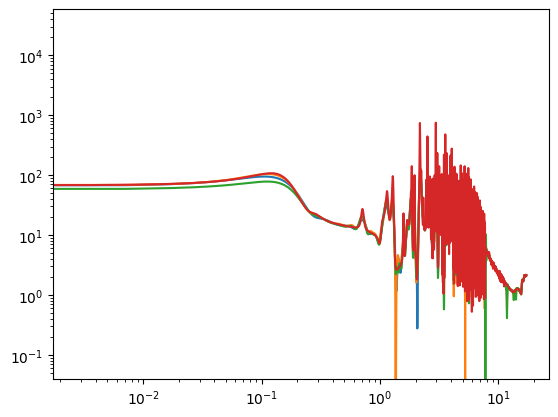

In [41]:
plt.plot(gp_results["Incident energy"], gp_results["ENDF/B-VIII.0"])
plt.plot(gp_results["Incident energy"], gp_results["BROND-3.1"])
plt.plot(gp_results["Incident energy"], gp_results["JEFF-4.0"])
plt.plot(Udat_gp["Incident energy"], Udat_gp["ENDF/B-VIII.0"])
plt.xscale("log")
plt.yscale("log")

In [5]:
prob_surf = pd.read_csv("C:/Users/jakeh/PycharmProjects/ML4ND_py/Gaussian-Process/output_folder/prob_surf.txt")
len(prob_surf["prob"])
#prob_surf.head()
#heatmap_data = prob_surf.pivot_table(index="Energy", columns="quantity", values="prob", aggfunc="mean")

16756900